# 01 - Exploratory Data Analysis
NFL Play-by-Play Data (2016-2023)
Goal: Understand the dataset, identify relevant features, and uncover data quality issues.

## 0. Setup

In [1]:
import sys
sys.path.append('..') #to find local models as src or config

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import importlib


'''Self modules'''
from src.data_loader import load_data
from config import FIGURES_EDA, PLOT_DPI, PLOT_PALETTE


os.makedirs(FIGURES_EDA, exist_ok=True) #check if finds path

sns.set_theme(style="whitegrid", palette=PLOT_PALETTE) #for clean white background with grids, hls softer colors
palette = sns.color_palette(PLOT_PALETTE) # set standard hls

plt.rcParams["figure.dpi"] = PLOT_DPI #higher resolutions

## 1. Load Data & First Look

In [2]:
df = load_data()
print(f"Shape: {df.shape[0]:,} Rows x {df.shape[1]} Columns")
df.head(10)

Cache found - loading data from: C:\Users\rapha\.kiro\projects\Predicting-American-Football-Plays\data\cache\pbp_raw.parquet
Shape: 385,991 Rows x 372 Columns


,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,out_of_bounds,home_opening_kickoff,qb_epa,xyac_epa,xyac_mean_yardage,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe
0,1.0,2016_01_BUF_BAL,2016091101,BAL,BUF,REG,1,None,None,None,...,0.0,1.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,36.0,2016_01_BUF_BAL,2016091101,BAL,BUF,REG,1,BAL,home,BUF,...,0.0,1.0,-0.955114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,58.0,2016_01_BUF_BAL,2016091101,BAL,BUF,REG,1,BAL,home,BUF,...,1.0,1.0,0.336466,NaN,NaN,NaN,NaN,NaN,0.460759,-46.075901
3,85.0,2016_01_BUF_BAL,2016091101,BAL,BUF,REG,1,BAL,home,BUF,...,0.0,1.0,0.644540,1.567466,9.753489,8.0,0.637670,0.530295,0.426425,57.357508
4,109.0,2016_01_BUF_BAL,2016091101,BAL,BUF,REG,1,BAL,home,BUF,...,0.0,1.0,-0.546209,NaN,NaN,NaN,NaN,NaN,0.456597,-45.659652
5,130.0,2016_01_BUF_BAL,2016091101,BAL,BUF,REG,1,BAL,home,BUF,...,0.0,1.0,0.918295,0.902478,6.106861,5.0,0.511323,0.226924,0.499703,50.029665
6,154.0,2016_01_BUF_BAL,2016091101,BAL,BUF,REG,1,BAL,home,BUF,...,0.0,1.0,-1.758915,NaN,NaN,NaN,NaN,NaN,0.239082,-23.908222
7,175.0,2016_01_BUF_BAL,2016091101,BAL,BUF,REG,1,BAL,home,BUF,...,0.0,1.0,-0.922621,NaN,NaN,NaN,NaN,NaN,0.073808,NaN
8,198.0,2016_01_BUF_BAL,2016091101,BAL,BUF,REG,1,BAL,home,BUF,...,0.0,1.0,-0.405048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,216.0,2016_01_BUF_BAL,2016091101,BAL,BUF,REG,1,BUF,away,BAL,...,0.0,1.0,-0.481404,0.766186,5.742206,4.0,0.664248,0.242037,0.454161,54.583949


In [3]:
cols = df.columns.tolist()

# join every 10 col with a comma separtor to get better view
formatted_cols = "\n".join([", ".join(cols[i:i+10]) for i in range(0, len(cols), 10)])

print("Columns:\n" + formatted_cols)

Columns:
play_id, game_id, old_game_id, home_team, away_team, season_type, week, posteam, posteam_type, defteam
side_of_field, yardline_100, game_date, quarter_seconds_remaining, half_seconds_remaining, game_seconds_remaining, game_half, quarter_end, drive, sp
qtr, down, goal_to_go, time, yrdln, ydstogo, ydsnet, desc, play_type, yards_gained
shotgun, no_huddle, qb_dropback, qb_kneel, qb_spike, qb_scramble, pass_length, pass_location, air_yards, yards_after_catch
run_location, run_gap, field_goal_result, kick_distance, extra_point_result, two_point_conv_result, home_timeouts_remaining, away_timeouts_remaining, timeout, timeout_team
td_team, td_player_name, td_player_id, posteam_timeouts_remaining, defteam_timeouts_remaining, total_home_score, total_away_score, posteam_score, defteam_score, score_differential
posteam_score_post, defteam_score_post, score_differential_post, no_score_prob, opp_fg_prob, opp_safety_prob, opp_td_prob, fg_prob, safety_prob, td_prob
extra_point_prob, two_point_

In [29]:
df["play_type"].value_counts(dropna=False)

play_type
pass           161921
run            113214
no_play         36231
kickoff         22356
punt            18358
None            11317
extra_point     10192
field_goal       8425
qb_kneel         3398
qb_spike          579
Name: count, dtype: int64

## 2. Class Balance: Pass or Run

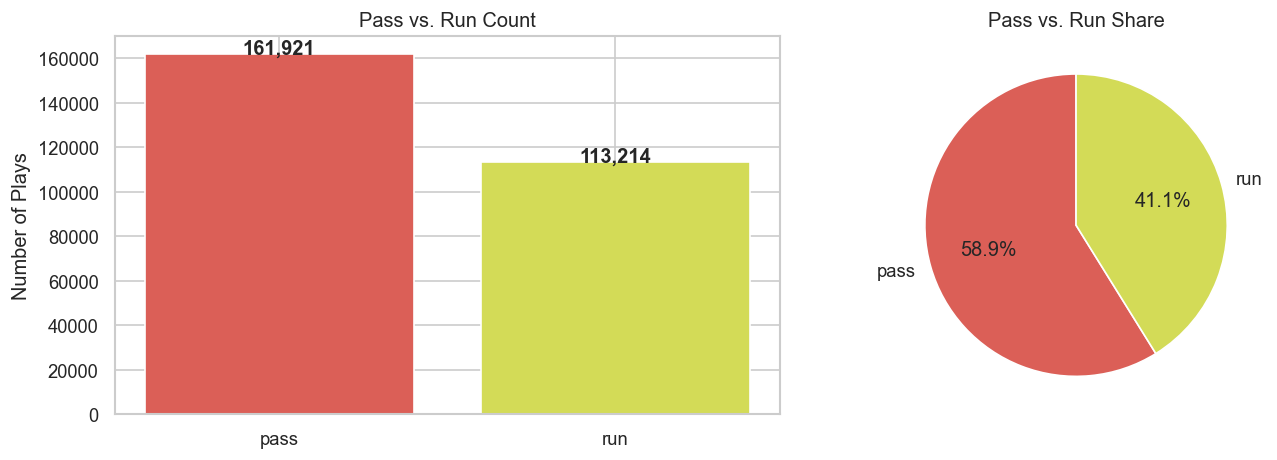

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) #change size
counts = plays["play_type"].value_counts() #count how many plays

axes[0].bar(counts.index, counts.values, color=palette) #plot barchart

axes[0].set_title("Pass vs. Run Count") # title
axes[0].set_ylabel("Number of Plays") # y lable

# calc percentages
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha="center", fontweight="bold")
pct = counts / counts.sum() * 100

# plot piechart
axes[1].pie(pct.values, labels=pct.index, autopct="%1.1f%%", colors=palette, startangle=90)
axes[1].set_title("Pass vs. Run Share")


plt.tight_layout()
plt.savefig(os.path.join(FIGURES_EDA, "class_balance.png"), bbox_inches="tight")
plt.show()

## 3. Play Type by Down

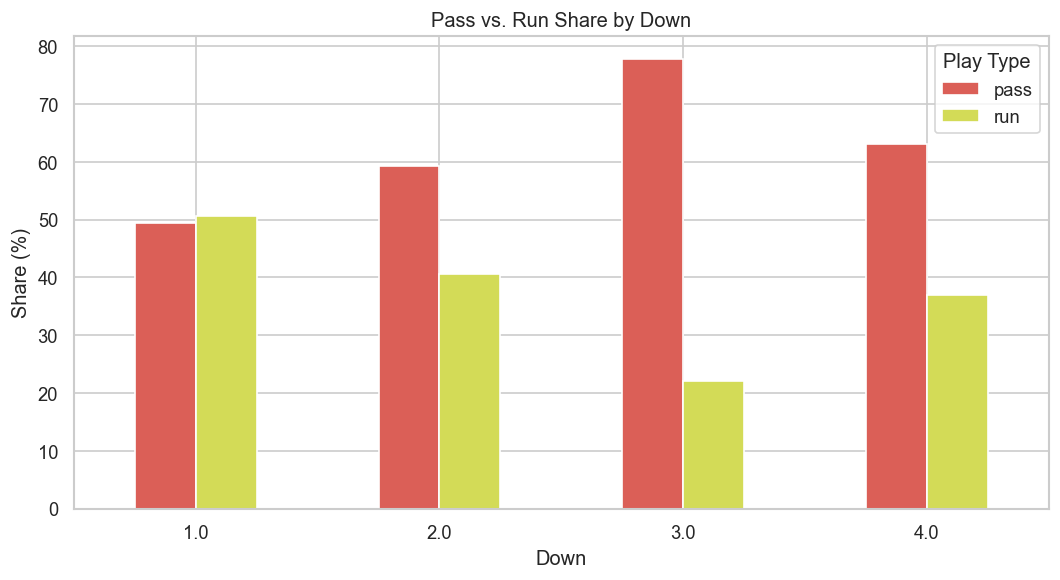

In [30]:
# calc percentages by down
down_pct = (
    plays.groupby(["down", "play_type"])
    .size().unstack()
    .apply(lambda x: x / x.sum() * 100, axis=1) # calc percentage
)

fig, ax = plt.subplots(figsize=(9, 5)) #change size

down_pct.plot(kind="bar", edgecolor="white", color=palette, ax=ax) #plot barchart

ax.set_title("Pass vs. Run Share by Down") # title
ax.set_xlabel("Down") # x label
ax.set_ylabel("Share (%)") # y label

ax.tick_params(axis="x", labelrotation=0) #rotate xticks
ax.legend(title="Play Type")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_EDA, "play_type_by_down.png"), bbox_inches="tight")
plt.show()

## 4. Pass Rate by Yards to Go

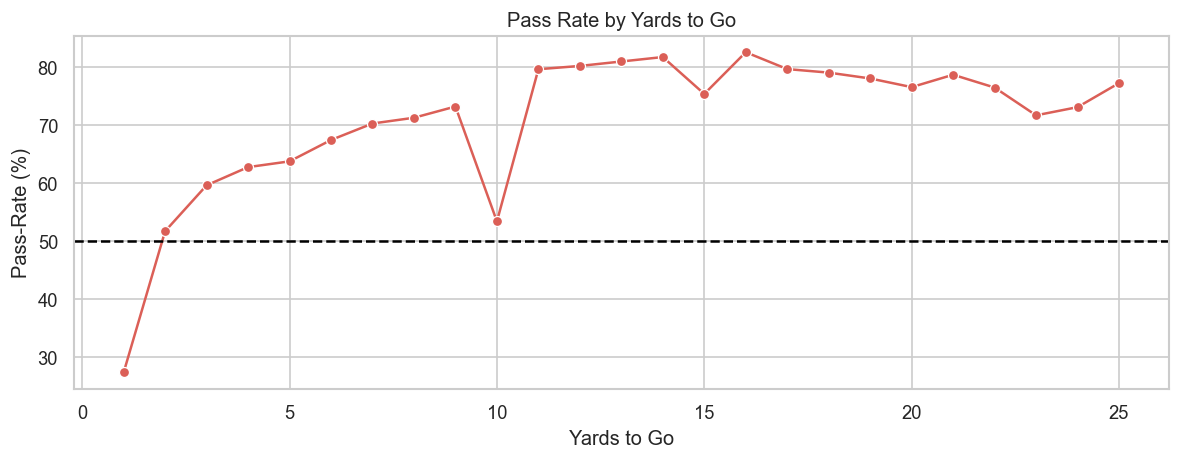

In [7]:
# calc pass rate by yards to go
ydstogo_pct = (
    plays[(plays["ydstogo"] > 0) & (plays["ydstogo"] <= 25)] #under 25 yards
    .groupby("ydstogo")["play_type"]
    .apply(lambda x: (x == "pass").mean() * 100)
    .reset_index(name="pass_rate")
)

fig, ax = plt.subplots(figsize=(10, 4)) #change size

sns.lineplot(data=ydstogo_pct, x="ydstogo", y="pass_rate", marker="o", color=palette[0], ax=ax) #plot lineplot
ax.axhline(50, color='black', linestyle="--", label="50%") #add baseline

ax.set_title("Pass Rate by Yards to Go") # title
ax.set_xlabel("Yards to Go") # x label
ax.set_ylabel("Pass-Rate (%)") # y label

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_EDA, "pass_rate_by_ydstogo.png"), bbox_inches="tight")
plt.show()

## 5. Pass Rate by Score Differential

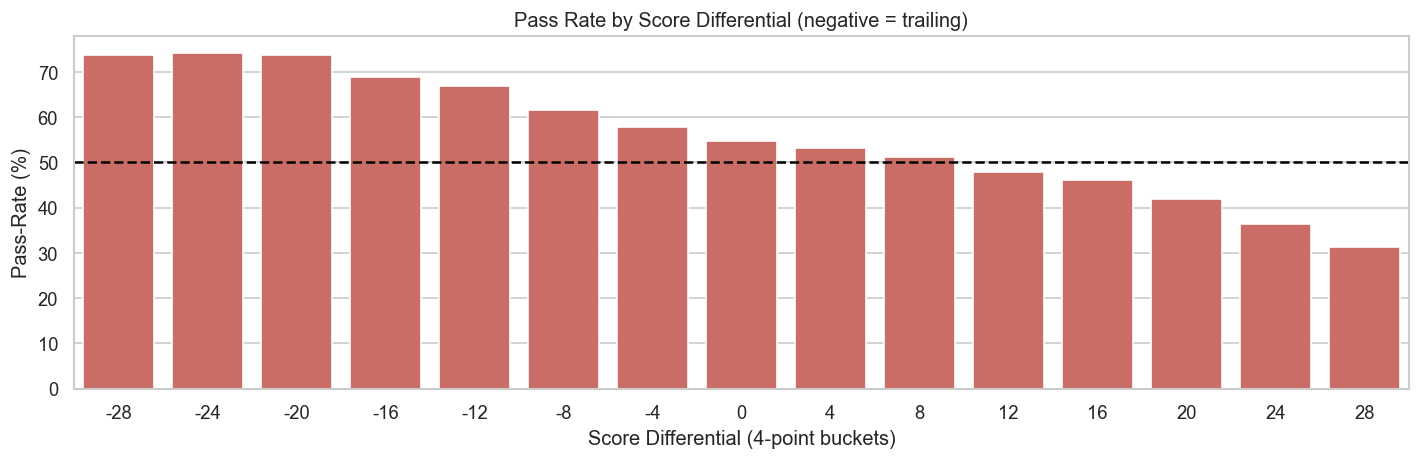

In [8]:
# calc pass rate by score differential buckets
score_df = plays.dropna(subset=["score_differential"]).copy()
score_df["score_bucket"] = pd.cut(score_df["score_differential"],
                                   bins=range(-28, 33, 4),
                                   labels=[f"{i}" for i in range(-28, 29, 4)])
score_pct = (
    score_df.groupby("score_bucket", observed=True)["play_type"]
    .apply(lambda x: (x == "pass").mean() * 100)
    .reset_index(name="pass_rate")
)

fig, ax = plt.subplots(figsize=(12, 4)) #change size

sns.barplot(data=score_pct, x="score_bucket", y="pass_rate", color=palette[0], ax=ax) #plot barchart
ax.axhline(50, color="black", linestyle="--") #add baseline

ax.set_title("Pass Rate by Score Differential (negative = trailing)") # title
ax.set_xlabel("Score Differential (4-point buckets)") # x label
ax.set_ylabel("Pass-Rate (%)") # y label

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_EDA, "pass_rate_by_score_diff.png"), bbox_inches="tight")
plt.show()

## 6. Pass Rate by Time Remaining

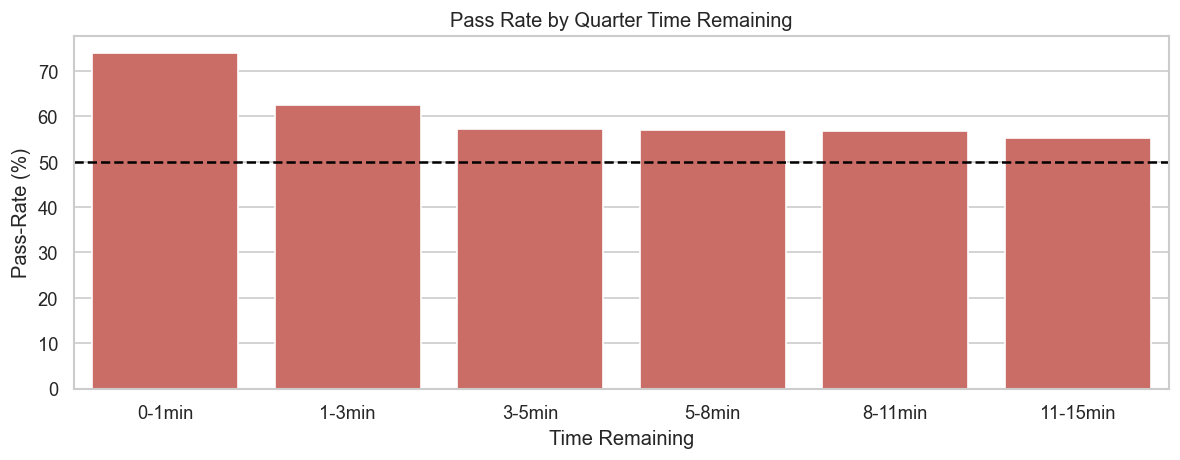

In [9]:
# calc pass rate by quarter time remaining buckets
time_df = plays.dropna(subset=["quarter_seconds_remaining"]).copy()
time_df["time_bucket"] = pd.cut(time_df["quarter_seconds_remaining"],
    bins=[0, 60, 180, 300, 480, 660, 900], 
    labels=["0-1min", "1-3min", "3-5min", "5-8min", "8-11min", "11-15min"])

time_pct = (time_df.groupby("time_bucket", observed=True)["play_type"]
    .apply(lambda x: (x == "pass").mean() * 100)  #calc % of pass plays mean of true/false * 100
    .reset_index(name="pass_rate"))

fig, ax = plt.subplots(figsize=(10, 4)) #change size

sns.barplot(data=time_pct, x="time_bucket", y="pass_rate", color=palette[0], ax=ax) #plot barchart
ax.axhline(50, color="black", linestyle="--") #add baseline

ax.set_title("Pass Rate by Quarter Time Remaining") # title
ax.set_xlabel("Time Remaining") # x label
ax.set_ylabel("Pass-Rate (%)") # y label

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_EDA, "pass_rate_by_quarter_time.png"), bbox_inches="tight")
plt.show()

## 7. Pass Rate by Field Position

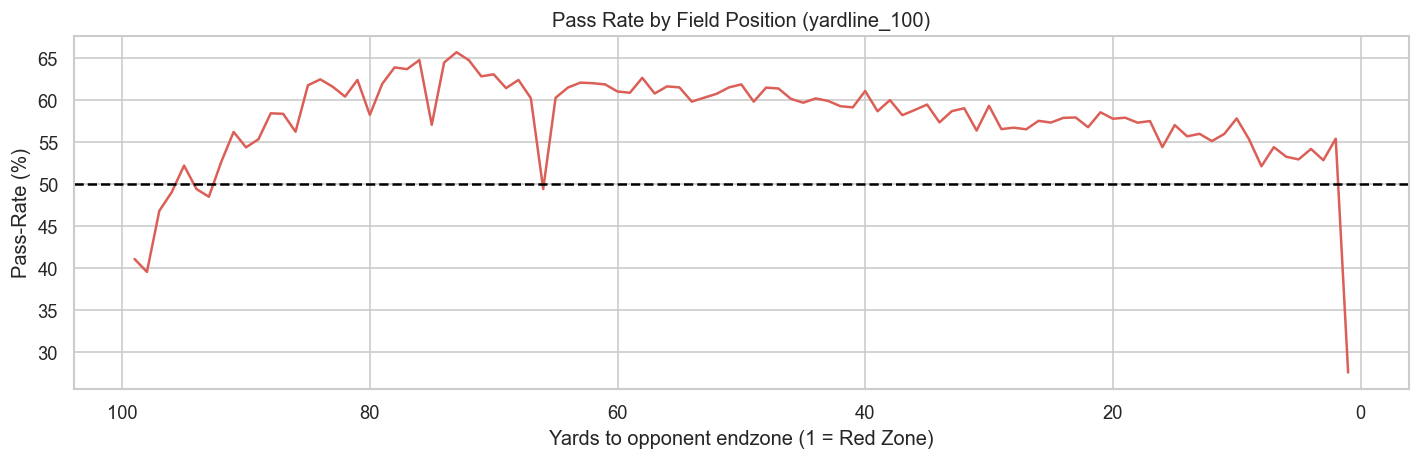

In [10]:
# calc pass rate by yardline
yard_pct = (plays[plays["yardline_100"] > 0] # make sure its not in touchdown zone
    .dropna(subset=["yardline_100"])
    .groupby("yardline_100")["play_type"]
    .apply(lambda x: (x == "pass").mean() * 100) # calc % of pass plays (mean of true/false * 100)
    .reset_index(name="pass_rate") # convert back to dataframe
)

fig, ax = plt.subplots(figsize=(12, 4)) #change size

sns.lineplot(data=yard_pct, x="yardline_100", y="pass_rate", color=palette[0], ax=ax) #plot lineplot
ax.axhline(50, color="black", linestyle="--") #add baseline
ax.invert_xaxis() #invert xaxis

ax.set_title("Pass Rate by Field Position (yardline_100)") # title
ax.set_xlabel("Yards to opponent endzone (1 = Red Zone)") # x label
ax.set_ylabel("Pass-Rate (%)") # y label

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_EDA, "pass_rate_by_yardline.png"), bbox_inches="tight")
plt.show()

## 8. Pass Rate per Season

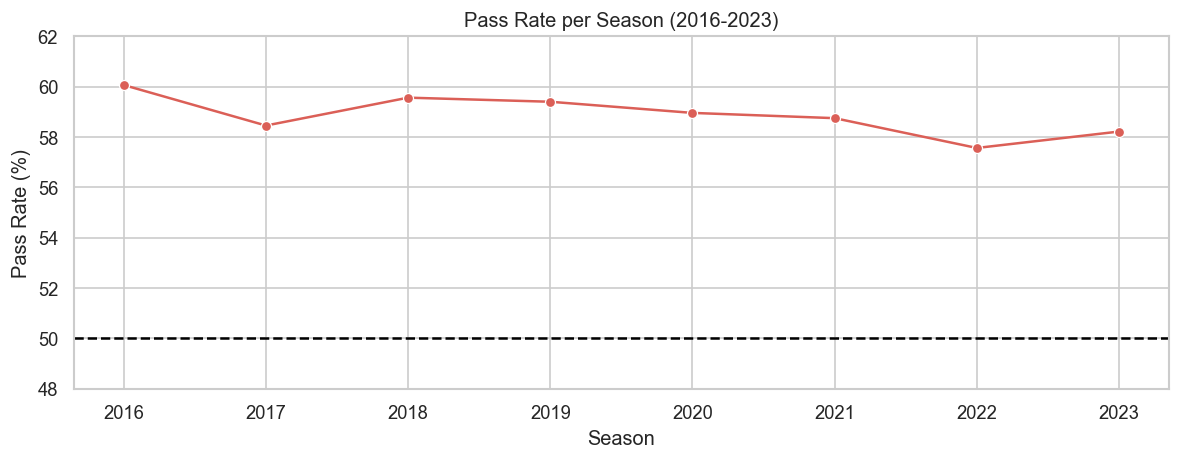

In [19]:
# calc pass rate by season
season_pct = (
    plays.groupby("season")["play_type"]
    .apply(lambda x: (x == "pass").mean() * 100) # calc % of pass plays (mean of true/false * 100)
    .reset_index(name="pass_rate")
)

fig, ax = plt.subplots(figsize=(10, 4)) #change size

sns.lineplot(data=season_pct, x="season", y="pass_rate", marker="o", color=palette[0], ax=ax) #plot lineplot
ax.axhline(50, color="black", linestyle="--") #add baseline
ax.set_ylim(48, 62)


ax.set_title("Pass Rate per Season (2016-2023)") # title
ax.set_xlabel("Season") # x label
ax.set_ylabel("Pass Rate (%)") # y label

ax.set_xticks(season_pct["season"]) #set xticks

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_EDA, "pass_rate_by_season.png"), bbox_inches="tight")
plt.show()